In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

import sys
sys.path.append('..')
from src.preprocess import load_raw, impute_bmi, impute_smoking

df_raw = load_raw('../data/healthcare-dataset-stroke-data.csv')
df = impute_bmi(df_raw.copy())
df = impute_smoking(df)
print(df.shape)
df.head()

(5109, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [2]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nClass distribution:')
print(df['stroke'].value_counts(normalize=True).round(4))

gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Missing values:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Class distribution:
stroke
0    0.9513
1    0.0487
Name: proportion, dtype: float64


## Chart 1 — Class Imbalance

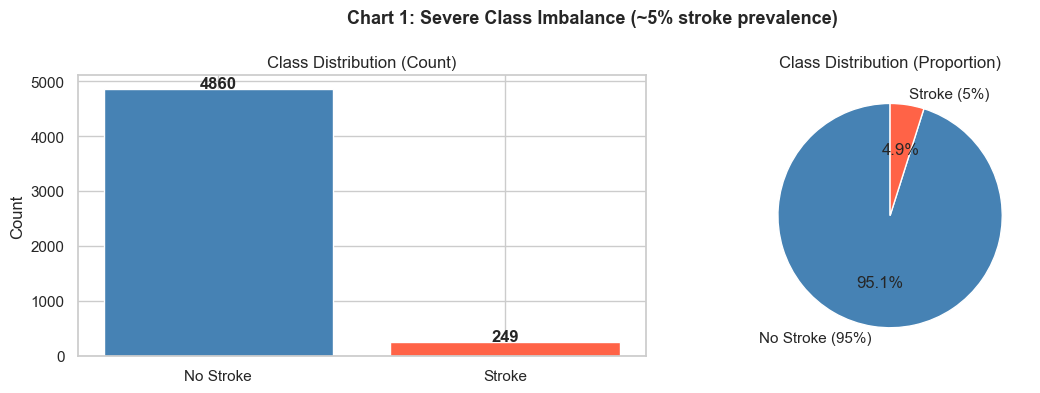

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['stroke'].value_counts()
axes[0].bar(['No Stroke', 'Stroke'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['No Stroke (95%)', 'Stroke (5%)'], colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (Proportion)')
plt.suptitle('Chart 1: Severe Class Imbalance (~5% stroke prevalence)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Chart 2 — Age Distribution by Stroke

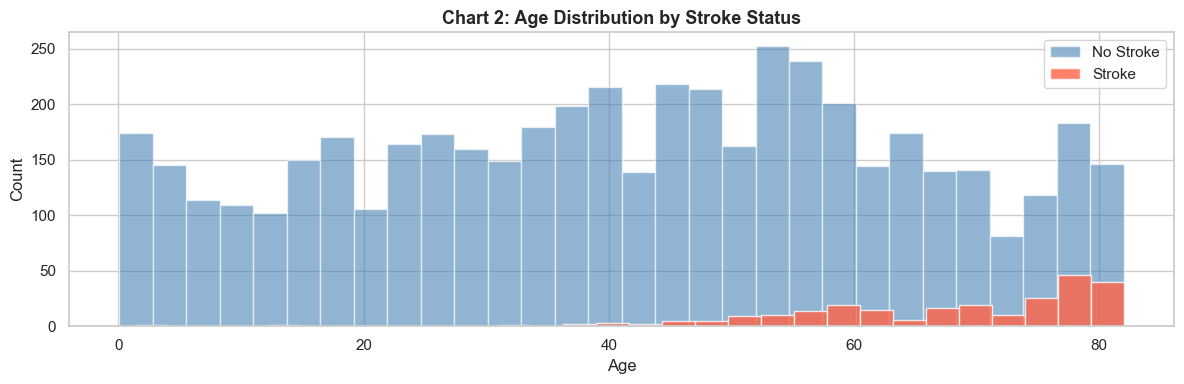

Mean age — No Stroke: 42.0, Stroke: 67.7


In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
df[df['stroke'] == 0]['age'].plot(kind='hist', bins=30, alpha=0.6, label='No Stroke', color='steelblue', ax=ax)
df[df['stroke'] == 1]['age'].plot(kind='hist', bins=30, alpha=0.8, label='Stroke', color='tomato', ax=ax)
ax.set_title('Chart 2: Age Distribution by Stroke Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Mean age — No Stroke: {df[df['stroke']==0]['age'].mean():.1f}, Stroke: {df[df['stroke']==1]['age'].mean():.1f}")

## Chart 3 — Glucose Level Distribution by Stroke

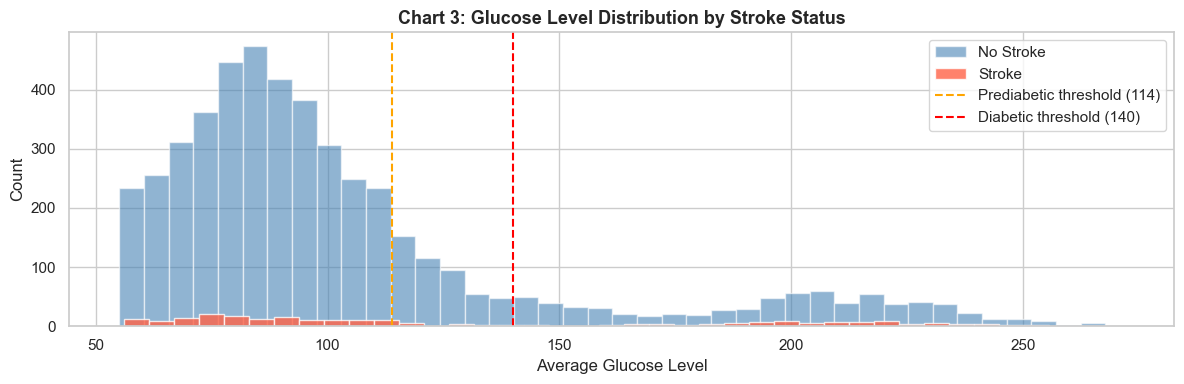

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
df[df['stroke'] == 0]['avg_glucose_level'].plot(kind='hist', bins=40, alpha=0.6, label='No Stroke', color='steelblue', ax=ax)
df[df['stroke'] == 1]['avg_glucose_level'].plot(kind='hist', bins=40, alpha=0.8, label='Stroke', color='tomato', ax=ax)
ax.axvline(114, color='orange', linestyle='--', label='Prediabetic threshold (114)')
ax.axvline(140, color='red', linestyle='--', label='Diabetic threshold (140)')
ax.set_title('Chart 3: Glucose Level Distribution by Stroke Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Glucose Level')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## Chart 4 — BMI Distribution by Stroke

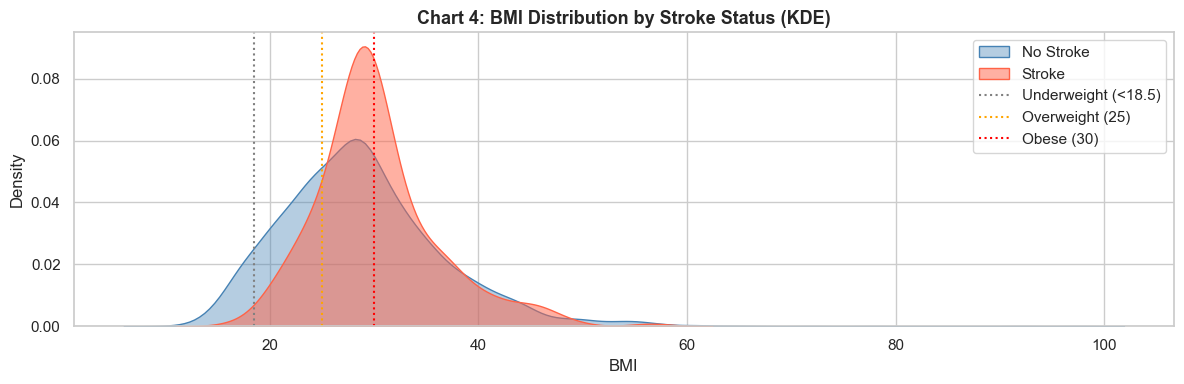

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.kdeplot(df[df['stroke'] == 0]['bmi'], label='No Stroke', fill=True, alpha=0.4, color='steelblue', ax=ax)
sns.kdeplot(df[df['stroke'] == 1]['bmi'], label='Stroke', fill=True, alpha=0.5, color='tomato', ax=ax)
ax.axvline(18.5, color='gray', linestyle=':', label='Underweight (<18.5)')
ax.axvline(25, color='orange', linestyle=':', label='Overweight (25)')
ax.axvline(30, color='red', linestyle=':', label='Obese (30)')
ax.set_title('Chart 4: BMI Distribution by Stroke Status (KDE)', fontsize=13, fontweight='bold')
ax.set_xlabel('BMI')
ax.legend()
plt.tight_layout()
plt.show()

## Chart 5 — Stroke Rate by Age Group

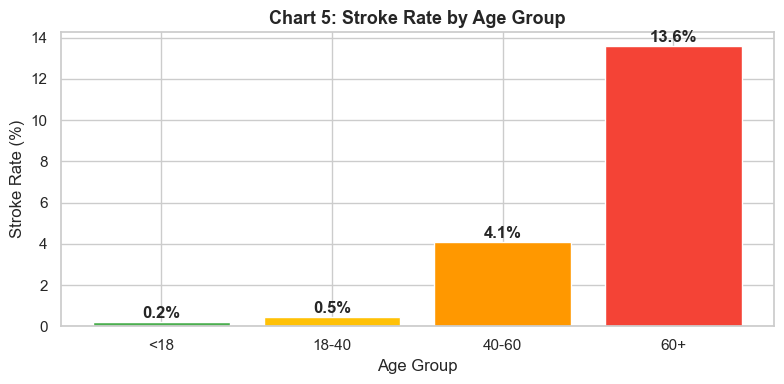

In [7]:
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 40, 60, 120], labels=['<18', '18-40', '40-60', '60+'])
stroke_by_age = df.groupby('age_group', observed=True)['stroke'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(stroke_by_age['age_group'].astype(str), stroke_by_age['stroke'] * 100, color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'])
for bar, val in zip(bars, stroke_by_age['stroke']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val*100:.1f}%', ha='center', fontweight='bold')
ax.set_title('Chart 5: Stroke Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Stroke Rate (%)')
plt.tight_layout()
plt.show()

## Chart 6 — Stroke Rate by Hypertension & Heart Disease

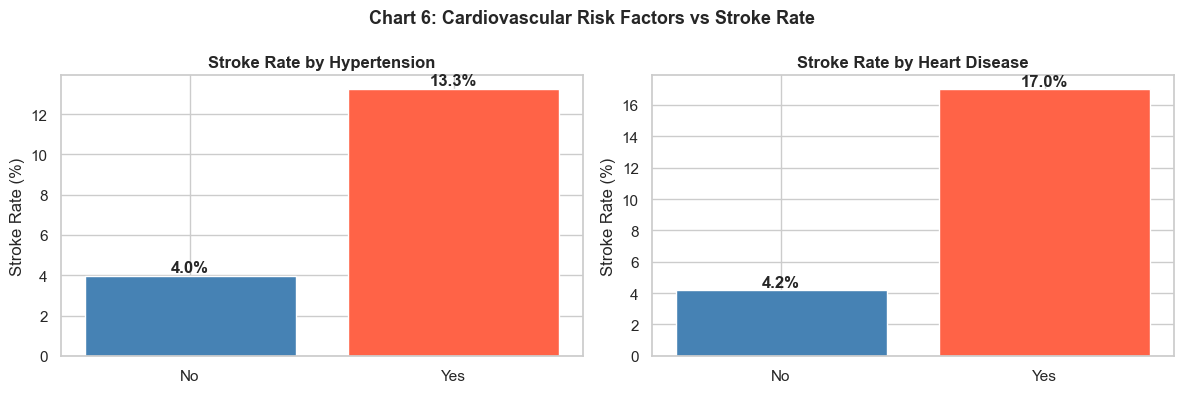

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ['hypertension', 'heart_disease'], ['Hypertension', 'Heart Disease']):
    rates = df.groupby(col)['stroke'].mean() * 100
    bars = ax.bar(['No', 'Yes'], rates.values, color=['steelblue', 'tomato'])
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}%', ha='center', fontweight='bold')
    ax.set_title(f'Stroke Rate by {label}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Stroke Rate (%)')
plt.suptitle('Chart 6: Cardiovascular Risk Factors vs Stroke Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Chart 7 — Correlation Heatmap

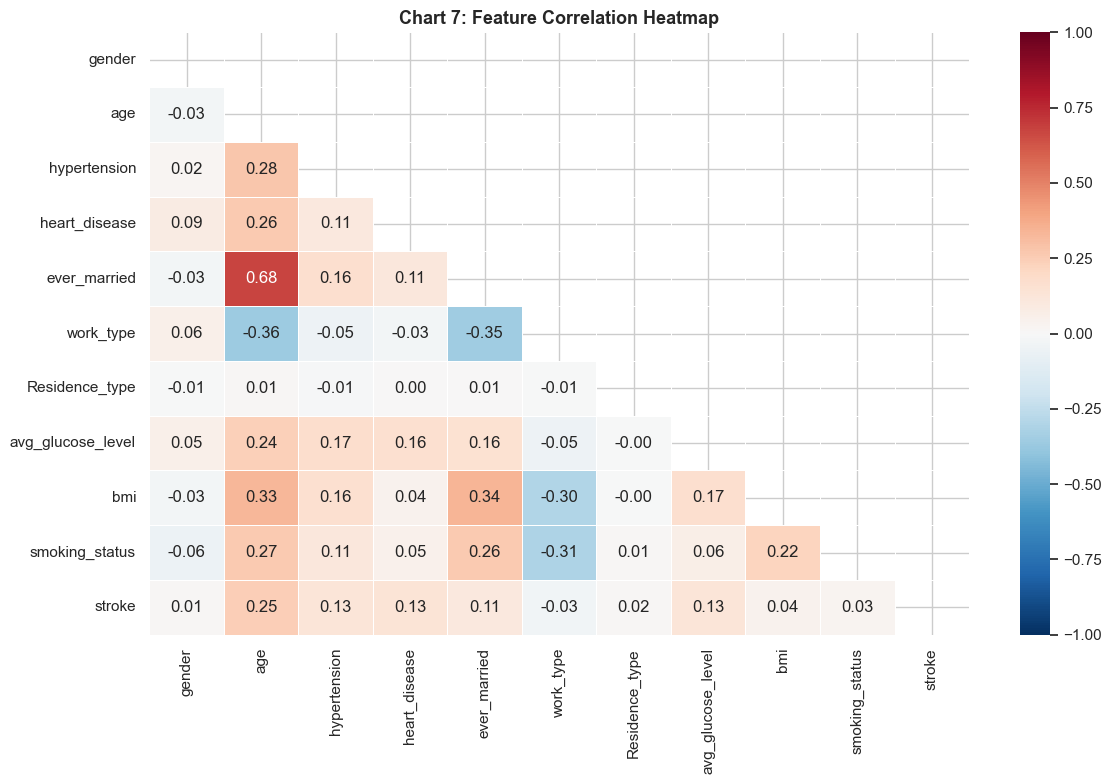

In [9]:
from sklearn.preprocessing import LabelEncoder
df_enc = df.copy()
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'age_group']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))
fig, ax = plt.subplots(figsize=(12, 8))
corr = df_enc.drop(columns=['age_group']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Chart 7: Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Chart 8 — Stroke Rate by Smoking Status

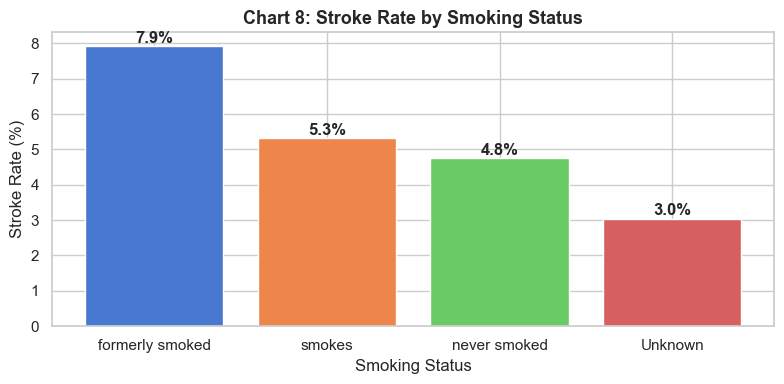

In [10]:
stroke_smoking = df.groupby('smoking_status')['stroke'].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(stroke_smoking.index, stroke_smoking.values, color=sns.color_palette('muted', len(stroke_smoking)))
for bar, val in zip(bars, stroke_smoking.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Chart 8: Stroke Rate by Smoking Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Smoking Status')
ax.set_ylabel('Stroke Rate (%)')
plt.tight_layout()
plt.show()

## Chart 9 — Work Type & Marital Status vs Stroke

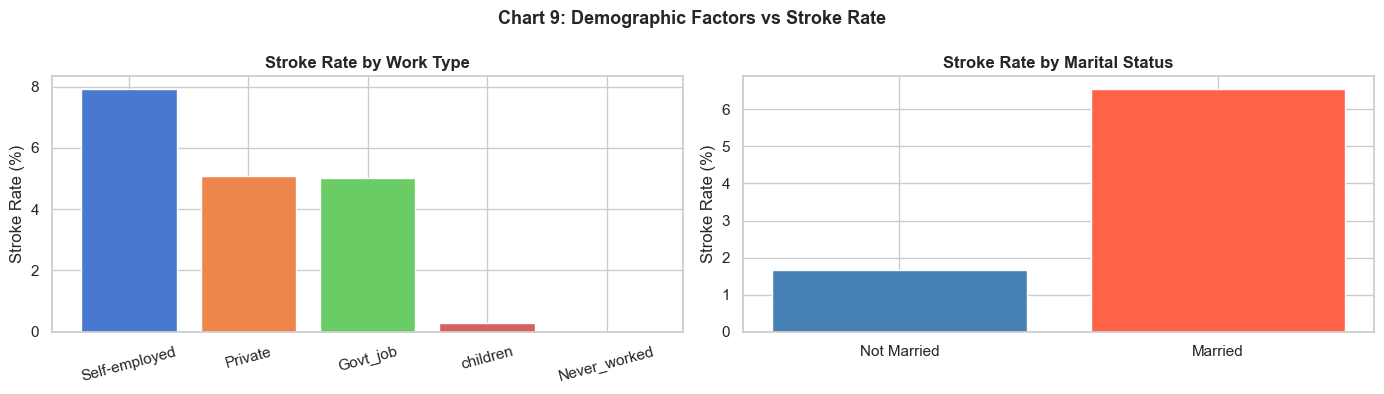

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
wt = df.groupby('work_type')['stroke'].mean().sort_values(ascending=False) * 100
axes[0].bar(wt.index, wt.values, color=sns.color_palette('muted', len(wt)))
axes[0].set_title('Stroke Rate by Work Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Stroke Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
ms = df.groupby('ever_married')['stroke'].mean() * 100
axes[1].bar(['Not Married', 'Married'], ms.values, color=['steelblue', 'tomato'])
axes[1].set_title('Stroke Rate by Marital Status', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Stroke Rate (%)')
plt.suptitle('Chart 9: Demographic Factors vs Stroke Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Chart 10 — Pairplot: Age, Glucose, BMI colored by Stroke

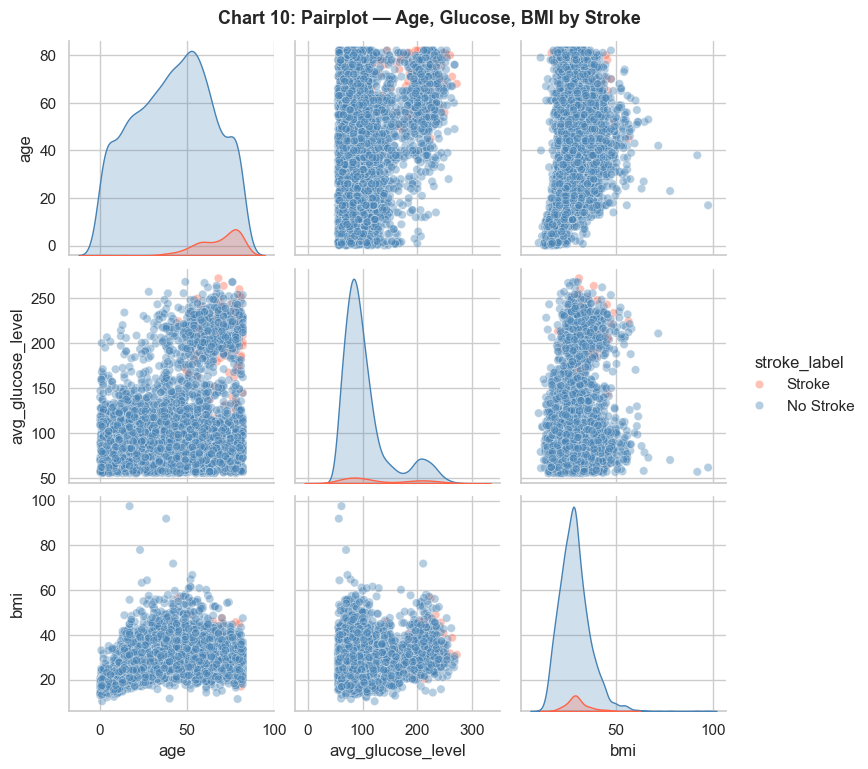

In [12]:
pair_df = df[['age', 'avg_glucose_level', 'bmi', 'stroke']].copy()
pair_df['stroke_label'] = pair_df['stroke'].map({0: 'No Stroke', 1: 'Stroke'})
g = sns.pairplot(pair_df.drop(columns=['stroke']), hue='stroke_label',
                 palette={'No Stroke': 'steelblue', 'Stroke': 'tomato'},
                 plot_kws={'alpha': 0.4}, diag_kind='kde')
g.figure.suptitle('Chart 10: Pairplot — Age, Glucose, BMI by Stroke', y=1.02, fontsize=13, fontweight='bold')
plt.show()